# Assignment 1

## Imports

In [1]:
import torch
import matplotlib.pyplot as plt
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.transforms import v2
from PIL import Image

## Task 1

### Part A — Basic Operations


1. Create tensors:
   * zeros
   * ones
   * random normal
   * random uniform
2. Perform and demonstrate:
   * elementwise multiplication
   * matrix multiplication
   * broadcasting
   * reshaping
   * transpose
   * concatenation
3. Show examples of incorrect shape operations and explain why they fail.

In [2]:
zeroes = torch.zeros(10)
ones = torch.ones(10)
normal = torch.randn(10)
uniform = torch.rand(10)

In [3]:
t1 = torch.tensor([1, 2, 3, 4])
t2 = torch.tensor([1, 2, 3, 4])

em = t1 * t2
mm = t1 @ t2
broadcasting = t1 + torch.randn(1)
reshaped = t1.reshape((2, 2))
transposed = reshaped.T
concatenated = torch.concatenate([t1, t2])

In [4]:
# t1 * torch.tensor([1, 2, 3])
# size difference (4 vs 3)

# t1.reshape((2, 3))
# cannot reshape to bigger size than original

# reshaped * torch.tensor([1, 2, 3])
# cannot broadcast second tensor to fit first one

### Part B — Manual Linear Algebra
Implement manually (without using torch.matmul for part of it):
* Dot product
* Matrix-vector multiplication
* Batch matrix multiplication

Then verify correctness using built-in PyTorch functions.

In [5]:
res = 0
for i in range(len(t1)):
    res += t1[i] * t2[i]

print(res)
print(t1 @ t2)

tensor(30)
tensor(30)


In [6]:
m1 = torch.tensor([1, 2, 3, 4, 5, 6]).reshape(3, 2)
v1 = torch.tensor([1, 2])

res = []
for i in range(m1.shape[0]):
    vector = 0
    for j in range(m1.shape[1]):
        vector += m1[i][j] * v1[j]
    res.append(vector)
print(torch.tensor(res))
print(m1 @ v1)

tensor([ 5, 11, 17])
tensor([ 5, 11, 17])


In [7]:
m1 = torch.randn(2, 3, 2)
m2 = torch.randn(2, 2, 4)

res = []
for b in range(m1.shape[0]):
    matrix = []
    for i in range(m1.shape[1]):
        vector = []
        for j in range(m2.shape[2]):
            elem_sum = 0
            for k in range(m1.shape[2]):
                elem_sum += m1[b, i, k] * m2[b, k, j]
            vector.append(elem_sum)
        matrix.append(vector)
    res.append(matrix)
print(torch.tensor(res))
print(torch.bmm(m1, m2))

tensor([[[ 0.0114, -2.1412, -0.2278,  1.3856],
         [ 1.7310,  0.5650, -1.4699, -0.4869],
         [-1.0008,  1.1553,  1.0006, -0.6781]],

        [[ 0.8845, -0.9244,  0.2109, -0.3795],
         [ 2.6297, -2.8702,  0.5163, -0.2089],
         [ 0.6294, -0.7282,  0.0862,  0.2605]]])
tensor([[[ 0.0114, -2.1412, -0.2278,  1.3856],
         [ 1.7310,  0.5650, -1.4699, -0.4869],
         [-1.0008,  1.1553,  1.0006, -0.6781]],

        [[ 0.8845, -0.9244,  0.2109, -0.3795],
         [ 2.6297, -2.8702,  0.5163, -0.2089],
         [ 0.6294, -0.7282,  0.0862,  0.2605]]])


### Required Explanation

Explain:

* Difference between elementwise and matrix multiplication.
* Broadcasting rules in PyTorch.
* Computational complexity of multiplying an n×mn \\times mn×m matrix with an m×km \\times km×k matrix.

$$
\begin{bmatrix}
a & b \\
c & d
\end{bmatrix}
$$
* Elementwise multiplication is a * a and matrix multiplication is a * a + b * c
* Broadcasting rules:
    * Shapes have to align from the right (2, 3) + (3,) -> (2, 3) + (1, 3) -> (2, 3) + (2, 3)
    * Dimension with size one gets expanded
* O(n * m * k)
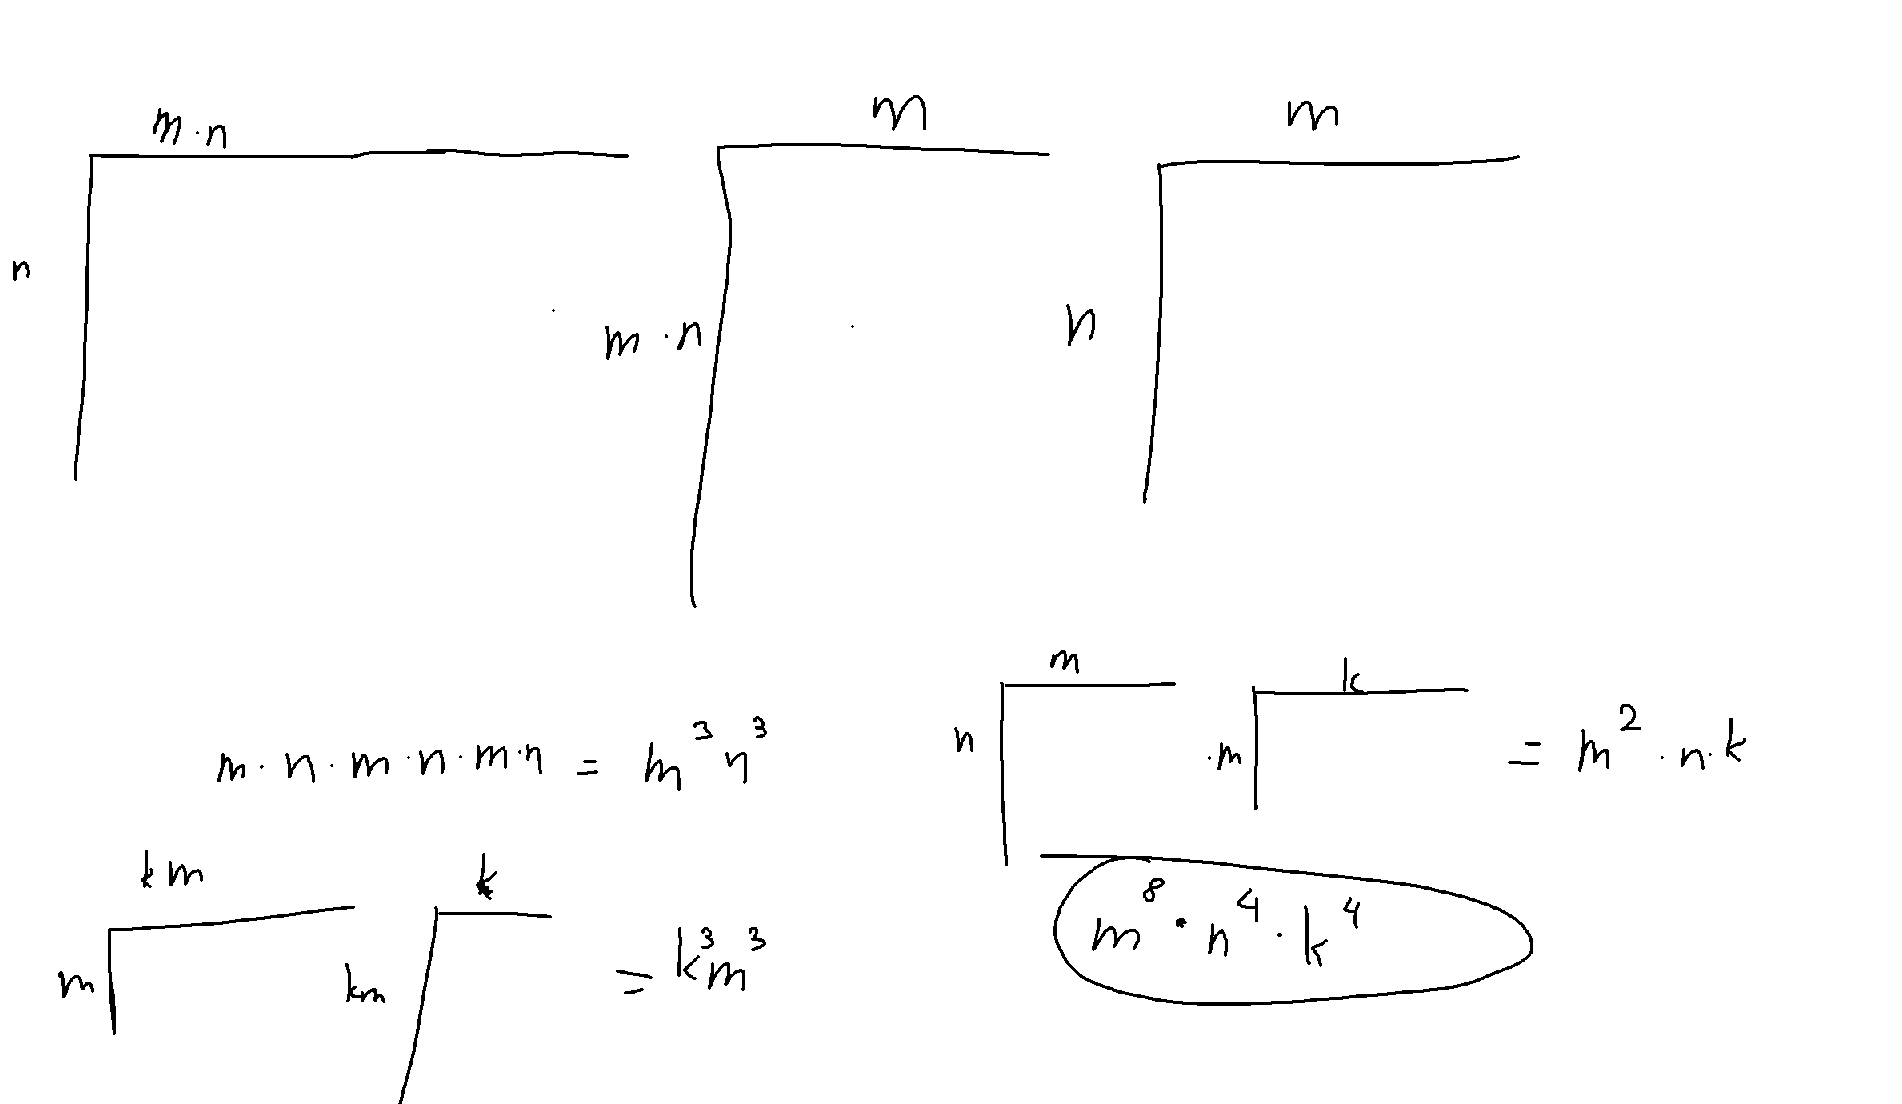

## Task 2

We consider the model:

$y = Wx+b$

### Requirements:
1. Generate synthetic dataset:
* 100 data points
* 1D input → 1D output
* Add small Gaussian noise
2. Initialize:
* W randomly
* b randomly
3. Compute:
* Predictions
* Mean Squared Error manually
4. Plot:
* Data points
* Model predictions

In [8]:
x = torch.rand(100)
noise = torch.randn(100) * 0.2

In [9]:
W = torch.rand(1)
b = torch.rand(1)

W_true = 2
b_true = 1

In [10]:
y_pred = W * x + b
y_true = W_true * x + b_true + noise

In [11]:
mse = ((y_pred - y_true)**2).mean()
print(f'MSE: {mse:.4f}')

MSE: 2.3024


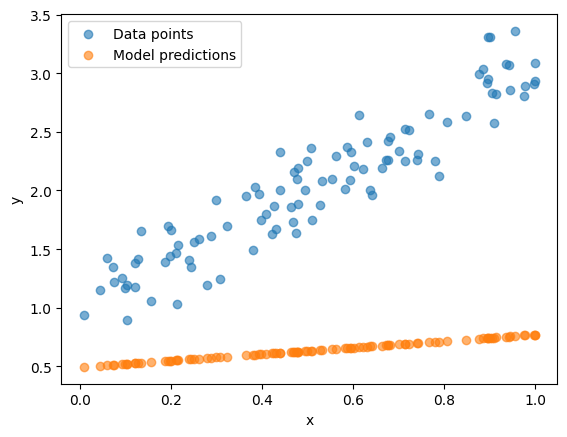

In [12]:
plt.scatter(x, y_true, label='Data points', alpha=0.6)
plt.scatter(x, y_pred, label='Model predictions', alpha=0.6)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

### Required Explanation:

* What does the weight represent geometrically?
* What does the bias represent?
* Why does random initialization produce poor predictions?

* Weight represents the slope of this line.
* Bias represents the vertical shift of the line from 0.
* Random initialized parameters have no relationship with original parameters.

## Task 3

#### Step 1 — Load Model
* Load pretrained ResNet18 from torchvision.models
* Set model.eval()

#### Step 2 — Image Preprocessing
* Load 3–5 images
* Apply correct transforms:
    * Resize
    * Center crop
    * To tensor
    * Normalization (ImageNet mean/std)

#### Step 3 — Inference
* Run forward pass
* Extract top-5 predicted classes
* Print class names and probabilities

#### Step 4 — Experiment
Run inference:
* With correct normalization
* Without normalization
Compare results.

In [13]:
model = resnet18(weights=ResNet18_Weights.DEFAULT)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [14]:
images = [Image.open(f'Images/{i}.jpg') for i in range(1, 4)]

In [15]:
images

[<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=343x355>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=760x500>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=612x531>]

In [16]:
# https://docs.pytorch.org/vision/stable/models/generated/torchvision.models.resnet18.html
# mean and std taken from here

transforms = v2.Compose([
    v2.Resize((256, 256)),
    v2.CenterCrop(224),
    v2.ToTensor(),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

/home/michal/PycharmProjects/Artificial-Inteligence/.venv/lib64/python3.13/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [17]:
x = transforms(images)

class_labels = ResNet18_Weights.DEFAULT.meta["categories"]
for image in x:
    pred = model(image.unsqueeze(0))
    probs = torch.softmax(pred, dim=1)
    top5_probs, top5_ids = torch.topk(probs, 5)
    for p, id in zip(top5_probs[0], top5_ids[0]):
        print(f'{class_labels[id.item()]}: {p.item():.4f}')
    print()

pinwheel: 0.5191
balloon: 0.2631
crash helmet: 0.0325
maraca: 0.0314
punching bag: 0.0208

kuvasz: 0.7730
Great Pyrenees: 0.1023
clumber: 0.0290
golden retriever: 0.0274
Labrador retriever: 0.0140

tiger cat: 0.2971
Egyptian cat: 0.2213
lynx: 0.1412
tabby: 0.1408
cougar: 0.0289



In [18]:
transforms_no_norm = v2.Compose([
    v2.Resize((256, 256)),
    v2.CenterCrop(224),
    v2.ToTensor()])

In [19]:
x = transforms_no_norm(images)

class_labels = ResNet18_Weights.DEFAULT.meta["categories"]
for image in x:
    pred = model(image.unsqueeze(0))
    probs = torch.softmax(pred, dim=1)
    top5_probs, top5_ids = torch.topk(probs, 5)
    for p, id in zip(top5_probs[0], top5_ids[0]):
        print(f'{class_labels[id.item()]}: {p.item():.4f}')
    print()

pinwheel: 0.9806
electric fan: 0.0087
lampshade: 0.0027
pick: 0.0009
table lamp: 0.0008

kuvasz: 0.7730
Great Pyrenees: 0.1023
clumber: 0.0290
golden retriever: 0.0274
Labrador retriever: 0.0140

tiger cat: 0.2971
Egyptian cat: 0.2213
lynx: 0.1412
tabby: 0.1408
cougar: 0.0289



Without normalization probability for pinwheel increased.

Required Explanation
In markdown, answer:
* Why do we call model.eval()?
* What happens if normalization is skipped?
* What is a logit?
* Why do we apply softmax for probabilities?

* model.eval() is called to disable all training features (for example Dropout layers)
* Not much changes, at least in my case. But if the model was trained on normalised inputs then we will have worse results.
* Logit is raw value from a model
* Logits are not probabilities. Softmax function transforms logits into probabilities.